# Análisis exploratorio de datos

## Configuración del path

In [2]:
# Configuración del path del proyecto
# Permite importar módulos desde la carpeta raíz `Data-science`
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

# Se agrega la raíz del proyecto si aún no está incluida.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

## Importacion de librerias

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

## Importación del dataset

In [4]:
# Importación del dataset
ruta = PROJECT_ROOT /'data'/'2_clean_data.csv'

# Leer el archivo
try:
    df = pd.read_csv(ruta, encoding='latin1', engine='python', on_bad_lines='skip')
    # Mostrar las primeras filas para verificar
    print("Archivo cargado exitosamente.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {ruta}")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Archivo cargado exitosamente.


,Text,clean_text,sentiment
0,I have bought several of the Vitality canned d...,bought vitality canned dog food products good ...,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,Negative
2,This is a confection that has been around a fe...,confection centuries light pillowy citrus gela...,Positive
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe g...,Negative
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,Positive


## Análisis de distribución de clases

In [5]:
# Creacion de columna de largo de texto
df['text_length'] = df['clean_text'].astype(str).apply(len)
df


,Text,clean_text,sentiment,text_length
0,I have bought several of the Vitality canned d...,bought vitality canned dog food products good ...,Positive,150
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...,Negative,136
2,This is a confection that has been around a fe...,confection centuries light pillowy citrus gela...,Positive,278
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe g...,Negative,117
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...,Positive,83
...,...,...,...,...
568449,Great for sesame chicken..this is a good if no...,great sesame chickenthis good better resturant...,Positive,91
568450,I'm disappointed with the flavor. The chocolat...,im disappointed flavor chocolate notes especia...,Negative,148
568451,"These stars are small, so you can give 10-15 o...",stars small training session tried train dog c...,Positive,227
568452,These are the BEST treats for training and rew...,best treats training rewarding dog good groomi...,Positive,117


In [6]:
# Estadisticas descriptivas de la columna largo de texto clasificada por sentimiento
df.groupby('sentiment')['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
Negative,82037.0,267.502676,283.252172,5.0,112.0,189.0,319.0,6506.0
Neutral,42640.0,287.813133,295.457880,15.0,116.0,202.0,362.0,13959.0
Positive,443777.0,235.164772,246.307068,3.0,97.0,160.0,281.0,10477.0


In [7]:
df['sentiment'].value_counts()

sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64

## Historgama

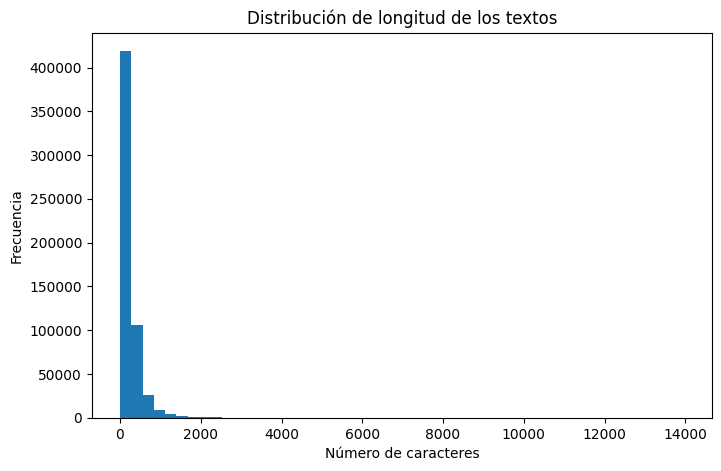

In [8]:
# Histograma de longitud de texto 

plt.figure(figsize=(8,5))
plt.hist(df['text_length'], bins=50)
plt.title('Distribución de longitud de los textos')
plt.xlabel('Número de caracteres')
plt.ylabel('Frecuencia')
plt.show()

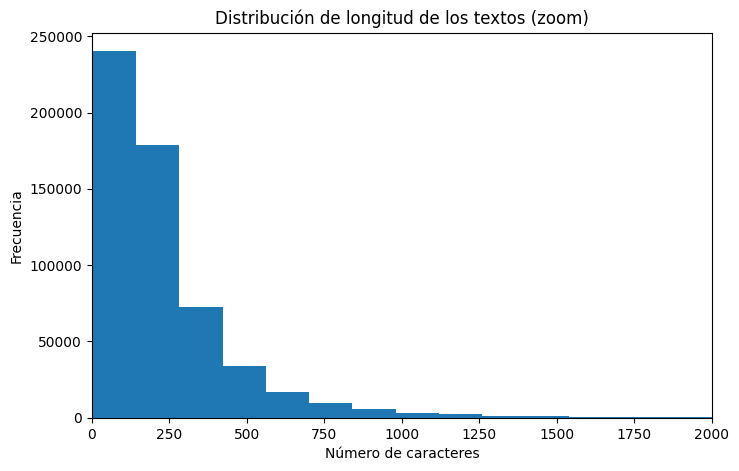

In [9]:
# Asegurar que existe text_length
df.columns = df.columns.str.strip()   # por si hay espacios raros
df["text_length"] = df["clean_text"].astype(str).str.len()

# Histograma (zoom) más "fino"

plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=100)   # más bins = más fino
plt.xlim(0, 2000)
plt.title("Distribución de longitud de los textos (zoom)")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")
plt.show()

73% de las reseñas tienen menos de 500 caracteres, lo que sugiere que la mayoría de los usuarios expresan su opinión de forma concisa. Los textos más largos representan una minoría y aportan variabilidad adicional al conjunto de datos.

## BOXPLOT de longitud por sentimiento

<Figure size 800x500 with 0 Axes>

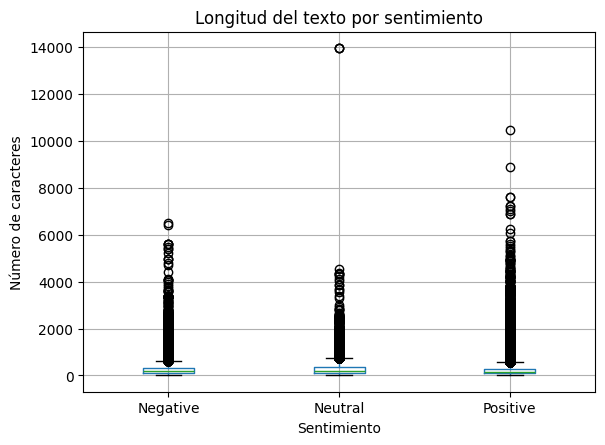

In [10]:
plt.figure(figsize=(8,5))
df.boxplot(column='text_length', by='sentiment')
plt.title('Longitud del texto por sentimiento')
plt.suptitle('')  # quita título automático
plt.xlabel('Sentimiento')
plt.ylabel('Número de caracteres')
plt.show()

1. Los comentarios negativos tienden a ser más largos, lo que sugiere que los usuarios explican más cuando están insatisfechos
2. Los comentarios positivos muestran mayor dispersión, reflejando desde opiniones breves hasta reseñas extensas.



## Ejemplos reales por sentimiento

In [11]:
df[['clean_text', 'sentiment']].groupby('sentiment').head(2)

,clean_text,sentiment
0,bought vitality canned dog food products good ...,Positive
1,product arrived labeled jumbo salted peanutsth...,Negative
2,confection centuries light pillowy citrus gela...,Positive
3,looking secret ingredient robitussin believe g...,Negative
45,little wholesome supermarket brands somewhat m...,Neutral
47,flavors good differce oaker oats brand mushy,Neutral


## Gráfica de cantidad de positivos / negativos / neutros

sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


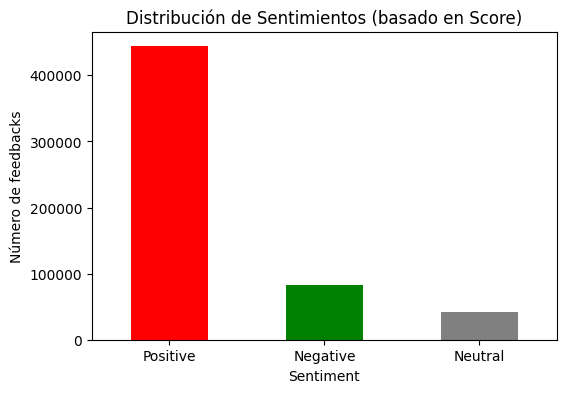

In [12]:

sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)



plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar', color=['red','green','gray'])
plt.title("Distribución de Sentimientos (basado en Score)")
plt.xlabel("Sentiment")
plt.ylabel("Número de feedbacks")
plt.xticks(rotation=0)
plt.show()

568 mil comentarios, cerca del 78% son positivos, alrededor del 14% negativos y solo un 8% neutros, lo que evidencia una fuerte inclinación del dataset hacia opiniones favorables.